# 5 Эффекты воздействия

При выполнении данного задания необходимо объединить обучающую и тестовую выборки в одну.

Далее каждый пункт оформлен в формате: номер задания, формулировка задания, выполнение задания.

Подключим библиотеки, которые используются в семинаре по эффектам воздействия: `statsmodels` для МНК, `doubleml` для двойного машинного обучения и модели `sklearn` для оценки условных средних и вероятностей.

In [1]:
import numpy as np
import pandas as pd
from copy import deepcopy
from scipy.stats import t, norm, uniform, logistic
import seaborn
import doubleml as dml
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.base import clone
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


Сначала загрузим полную выборку, обучающую и тестовую части, а также полный симуляционный датасет с потенциальными исходами из раздела 2.

In [2]:
df_observed = pd.read_csv('df.csv')
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')
df_full = pd.read_csv('df_full.csv')

print(pd.DataFrame(data    = [df_observed.shape[0], df_full.shape[0], df_train.shape[0], df_test.shape[0], df_train.shape[0] + df_test.shape[0]],
                   index   = ['df', 'df_full', 'df_train', 'df_test', 'df_train + df_test'],
                   columns = ['число наблюдений']))
print(df_observed.columns.tolist())


                    число наблюдений
df                             30000
df_full                        30000
df_train                       22500
df_test                         7500
df_train + df_test             30000
['monthly_spending', 'premium_subscription', 'income', 'age', 'urban_area', 'family_size', 'free_trial_banner']


В полной выборке 30000 наблюдений: 22500 из обучающей части и 7500 из тестовой. Значит для раздела 5 используется объединенная выборка, как требуется в задании.

В `df_full.csv` сохранены наблюдаемые переменные, потенциальные исходы и служебные переменные симуляции из раздела 2. Поэтому для расчета истинных ATE, LATE и CATE повторная генерация данных здесь не нужна.

Далее проверим согласованность наблюдаемых колонок и будем использовать сохраненные потенциальные исходы.

In [3]:
n = df_full.shape[0]


Инструментальная переменная `free_trial_banner` уже сохранена в полном датасете вместе с вероятностью и индексом ее генерации.

Потенциальные значения переменной воздействия `premium1` и `premium0` также читаются из полного датасета. Разница между ними нужна для выделения соблюдателей при расчете LATE.

Потенциальные исходы зависимой переменной `monthly_spending0` и `monthly_spending1` читаются из полного датасета.

Проверим, что наблюдаемые переменные в `df_full.csv` совпадают с сохраненным `df.csv`. После этого будем использовать полный датасет для доступа к потенциальным исходам, которые в реальных данных были бы ненаблюдаемыми.

In [4]:
observed_cols = ['monthly_spending', 'premium_subscription', 'income', 'age',
                 'urban_area', 'family_size', 'free_trial_banner']

check = pd.Series({col: np.allclose(df_observed[col], df_full[col]) for col in observed_cols}, name = 'совпадает')
print(check)

df = df_full.copy()


monthly_spending        True
premium_subscription    True
income                  True
age                     True
urban_area              True
family_size             True
free_trial_banner       True
Name: совпадает, dtype: bool


Все наблюдаемые переменные совпадают. Значит потенциальные исходы и служебные переменные загружены из той же генерации данных, что и наблюдаемый `df.csv`.

Истинные `ATE`, `LATE`, `ATET` и распределение истинного `CATE` будем считать на полной объединенной выборке из 30000 наблюдений. После этого, как разрешено в примечании к заданию, для оценок по наблюдаемым данным используем рабочую подвыборку из 10000 наблюдений.

In [5]:
df_effects_full = df.copy()

monthly_spending_full = np.array(df_effects_full['monthly_spending'])
premium_subscription_full = np.array(df_effects_full['premium_subscription'])
free_trial_banner_full = np.array(df_effects_full['free_trial_banner'])
monthly_spending0_full = np.array(df_effects_full['monthly_spending0'])
monthly_spending1_full = np.array(df_effects_full['monthly_spending1'])
g0_full = np.array(df_effects_full['g0'])
g1_full = np.array(df_effects_full['g1'])
compliers_full = np.array(df_effects_full['ind_type'] == 'Complier')

df = df_effects_full.sample(n = 10000, random_state = 777).reset_index(drop = True)

monthly_spending = np.array(df['monthly_spending'])
premium_subscription = np.array(df['premium_subscription'])
free_trial_banner = np.array(df['free_trial_banner'])
monthly_spending0 = np.array(df['monthly_spending0'])
monthly_spending1 = np.array(df['monthly_spending1'])
g0 = np.array(df['g0'])
g1 = np.array(df['g1'])
compliers = np.array(df['ind_type'] == 'Complier')

df.head(10).style.format(precision = 2)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner,income_z,age_center,online_preference_raw,online_preference,free_trial_banner_index,free_trial_banner_prob,premium_index,premium_segment,premium1_prob,premium0_prob,premium1,premium0,ind_type,error0,error1,base_spending,g0_obs,g0_unobs,g0,treatment_effect_structural,g1_obs,g1_unobs,g1,monthly_spending0,monthly_spending1,TE,CATE
0,6871.32,0,162012.34,44.00,1,1,1,1.79,0.90,-1.79,0.14,0.75,0.77,-0.99,0.00,0.49,0.27,0,0,Never taker,508.27,1542.19,8868.97,8868.97,-2505.92,6363.05,6261.78,15130.75,-5547.53,9583.21,6871.32,11125.40,4254.08,3220.16
1,807.83,0,48708.57,54.00,1,2,0,-0.61,1.90,-1.24,0.23,-1.21,0.11,-3.25,0.00,0.08,0.04,0,0,Never taker,-1278.74,4733.51,3873.23,3873.23,-1786.65,2086.58,5007.51,8880.74,-3985.78,4894.96,807.83,9628.46,8820.63,2808.38
2,21833.26,1,330566.83,49.00,1,4,1,3.22,1.40,-1.09,0.25,0.75,0.77,0.67,1.00,0.87,0.66,1,0,Complier,-1091.54,-1574.60,16226.59,16226.59,-1584.24,14642.35,10721.79,26948.38,-3540.53,23407.85,13550.82,21833.26,8282.44,8765.50
3,5229.59,0,83036.41,18.00,1,2,0,0.45,-1.70,-0.47,0.38,0.44,0.67,-1.46,0.00,0.33,0.19,0,0,Never taker,-109.83,631.82,6044.08,6044.08,-704.66,5339.42,5527.46,11571.54,-1583.34,9988.20,5229.59,10620.02,5390.43,4648.78
4,2667.66,0,27458.50,44.00,0,2,0,-1.76,0.90,-2.36,0.09,-1.94,0.03,-3.45,0.00,0.06,0.03,0,0,Never taker,3479.18,2171.81,2374.28,2374.28,-3185.79,-811.52,3960.47,6334.75,-6992.01,-657.26,2667.66,1514.55,-1153.11,154.26
5,12512.81,0,117613.27,18.00,1,4,1,1.15,-1.70,0.58,0.64,0.38,0.65,1.66,1.00,0.95,0.84,0,0,Never taker,1163.58,6994.07,10489.13,10489.13,860.10,11349.23,9133.81,19622.94,1931.32,21554.26,12512.81,28548.33,16035.51,10205.03
6,11247.09,1,25809.83,35.00,0,4,0,-1.88,0.00,0.60,0.64,-2.24,0.01,-1.19,0.00,0.39,0.23,1,1,Always taker,-3066.09,-435.30,3746.28,3746.28,884.08,4630.36,5951.16,9697.44,1984.95,11682.39,1564.27,11247.09,9682.82,7052.03
7,7990.00,0,60320.84,48.00,1,5,0,-0.19,1.30,-0.38,0.41,-1.51,0.07,-0.17,1.00,0.71,0.46,1,0,Complier,-288.33,149.31,8845.38,8845.38,-567.05,8278.33,8234.37,17079.75,-1274.75,15805.00,7990.00,15954.31,7964.31,7526.67
8,14253.31,1,67487.11,26.00,1,1,1,0.04,-0.90,1.32,0.79,0.21,0.58,0.60,0.00,0.79,0.65,1,1,Always taker,370.53,-186.44,4877.57,4877.57,1895.64,6773.21,5337.63,10215.20,4224.55,14439.75,7143.74,14253.31,7109.57,7666.54
9,5479.22,0,39995.90,51.00,0,4,0,-1.01,1.60,-0.52,0.37,-2.16,0.02,-3.12,0.00,0.09,0.04,0,0,Never taker,2135.91,-2602.15,4124.53,4124.53,-781.22,3343.31,5760.22,9884.75,-1754.83,8129.93,5479.22,5527.78,48.56,4786.62


Полная выборка используется для эталонных эффектов из потенциальных исходов. Рабочая подвыборка содержит те же наблюдаемые переменные, потенциальные исходы `monthly_spending0`, `monthly_spending1`, условные средние `g0`, `g1` и тип клиента относительно инструмента. Все дальнейшие оценки, основанные только на наблюдаемых данных, считаются на этой рабочей подвыборке.

## 5.1

**Задание.** Математически запишите выражения для ATE и LATE (с учетом специфики обозначений ваших переменных). Содержательно проинтерпретируйте, что они отражают в вашем исследовании.

**Выполнение задания.**

В обозначениях проекта `monthly_spending1` — потенциальные месячные траты клиента при наличии премиум-подписки, а `monthly_spending0` — потенциальные месячные траты без премиум-подписки.

Средний эффект воздействия:

$$ATE = E(monthly\_spending1_i - monthly\_spending0_i).$$

Он показывает, насколько в среднем меняются месячные траты клиента при переходе к премиум-подписке.

Локальный средний эффект воздействия:

$$LATE = E(monthly\_spending1_i - monthly\_spending0_i \mid premium1_i > premium0_i).$$

Он показывает средний эффект подписки для соблюдателей: клиентов, которые оформили бы премиум-подписку при показе баннера и не оформили бы ее без баннера.

Здесь индикатор воздействия наблюдается как

$$premium\_subscription_i = \begin{cases}premium1_i\text{, если }free\_trial\_banner_i = 1\\ premium0_i\text{, если }free\_trial\_banner_i = 0\end{cases}$$

Поэтому различие между `ATE` и `LATE` содержательно связано с тем, что инструмент меняет решение о подписке не у всех клиентов, а только у части из них.

## 5.2

**Задание.** Используя симулированные вами, но недоступные в реальных данных потенциальные исходы (гипотетические значения), получите оценки среднего эффекта воздействия, условных средних эффектов воздействия и локального среднего эффекта воздействия. Для ATE и LATE результаты представьте в форме таблицы, а для CATE постройте гистограмму или ядерную оценку функции плотности. Проинтерпретируйте полученные значения.

**Выполнение задания.**

Сначала рассчитаем индивидуальные эффекты воздействия как разность двух потенциальных исходов:

$$TE_i = monthly\_spending1_i - monthly\_spending0_i.$$

Тогда средний эффект воздействия можно оценить напрямую как:

$$\widehat{ATE} = \frac{1}{n}\sum\limits_{i=1}^{n} TE_i.$$

Локальный средний эффект воздействия для соблюдателей оценивается как:

$$\widehat{LATE} = \frac{1}{n_c}\sum\limits_{i: premium1_i > premium0_i} TE_i,$$

где $n_c$ — число соблюдателей.

Условный средний эффект воздействия в симуляции имеет вид:

$$CATE_i = E(monthly\_spending1_i \mid X_i) - E(monthly\_spending0_i \mid X_i).$$

В нашем случае `g0` и `g1` из DGP зависят не только от наблюдаемых признаков `income`, `age`, `urban_area`, `family_size`, но и от скрытой `online_preference`. Поэтому далее истинный `CATE` трактуется как oracle/simulation `CATE` по полной DGP с учетом скрытой компоненты, а не как `CATE`, который можно было бы восстановить только по наблюдаемым `X`.

In [6]:
TE_full = monthly_spending1_full - monthly_spending0_full
TE = monthly_spending1 - monthly_spending0
print(TE_full[0:10])

[ 5537.33307746  2487.70860932  -206.34559745  1986.29875689
  3495.98936191   629.63053737  8548.97004765  9523.01729882
 10149.03869903  9038.23390467]


Первые значения показывают, что эффект премиум-подписки неодинаков для разных клиентов. Это ожидаемо, потому что в генерации эффект зависит от дохода, города, размера семьи, возраста и ненаблюдаемой онлайн-склонности.

Оценим `ATE`, `LATE` и `ATET` напрямую по потенциальным исходам на полной объединенной выборке. Такая возможность есть только в симуляции, поэтому эти величины играют роль эталона, относительно которого затем удобно сравнивать оценки на наблюдаемых данных.

Содержательно получаем следующую картину. Истинный средний эффект воздействия равен примерно `6293`, то есть премиум-подписка в среднем заметно увеличивает месячные траты клиента. Истинный локальный эффект `LATE` равен примерно `6280` и очень близок к `ATE`. Это означает, что для соблюдателей, то есть клиентов, которых можно подтолкнуть к подписке показом баннера, эффект подписки примерно сопоставим со средним эффектом по всей выборке.

Оценка `ATET` выше, около `7275`, что естественно интерпретируется как более сильный эффект среди тех клиентов, которые в наблюдаемой выборке реально получили воздействие. Уже на этом шаге видно, что разные целевые параметры относятся к разным группам клиентов, поэтому в дальнейшем нельзя механически сопоставлять `ATE`, `ATET` и `LATE` как одно и то же число.

In [7]:
ATE = np.mean(TE_full)
LATE = np.mean(TE_full[compliers_full])
ATET = np.mean(TE_full[premium_subscription_full == 1])

print(pd.DataFrame(data    = [ATE, LATE, ATET],
                   index   = ['ATE', 'LATE', 'ATET'],
                   columns = ['Оценка']))

           Оценка
ATE   6292.960475
LATE  6280.319157
ATET  7274.638232


На полной объединенной выборке средний эффект подписки положителен: премиум-подписка заметно увеличивает месячные траты. LATE относится не ко всем клиентам, а к соблюдателям: тем, чье решение о подписке меняется под воздействием баннера.

Теперь рассчитаем CATE как разность условных средних потенциальных исходов и построим гистограмму распределения условных эффектов.

[7783.71913682 6017.36120987 5772.2814999   939.14593385 6502.53104396
 5183.59795207 8234.62453899 5998.69725844 6951.41474348 8082.28595026]


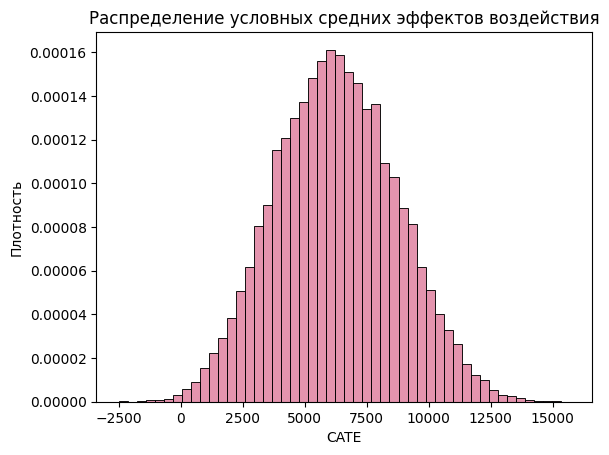

In [8]:
CATE_full = g1_full - g0_full
CATE = g1 - g0
print(CATE_full[0:10])

seaborn.histplot(CATE_full,
                 stat  = 'density',
                 color = 'palevioletred',
                 bins  = 50)
plt.xlabel('CATE')
plt.ylabel('Плотность')
plt.title('Распределение условных средних эффектов воздействия')
plt.show()

Распределение CATE показывает гетерогенность эффекта: премиум-подписка приносит разный прирост месячных трат для разных сегментов клиентов.

## 5.3

**Задание.** Оцените средний эффект воздействия как разницу в средних по выборкам тех, кто получил и не получил воздействие. Опишите недостатки соответствующего подхода с учетом специфики рассматриваемой вами экономической проблемы.

**Выполнение задания.**

Наивная оценка опирается на допущение независимости:

$$E(monthly\_spending1_i \mid premium\_subscription_i = 1) = E(monthly\_spending1_i),$$
$$E(monthly\_spending0_i \mid premium\_subscription_i = 0) = E(monthly\_spending0_i).$$

Тогда средний эффект воздействия оценивается как разница выборочных средних:

$$\widehat{ATE}_{naive} = \frac{1}{n_1}\sum\limits_{i: premium\_subscription_i = 1} monthly\_spending_i - \frac{1}{n_0}\sum\limits_{i: premium\_subscription_i = 0} monthly\_spending_i.$$

В нашей задаче это допущение не выполняется, потому что на решение о подписке и на траты одновременно влияет ненаблюдаемая `online_preference`.

In [9]:
ATE_naive = np.mean(monthly_spending[premium_subscription == 1]) - np.mean(monthly_spending[premium_subscription == 0])

print(pd.DataFrame(data    = [ATE, ATE_naive],
                   index   = ['ATE', 'ATE naive'],
                   columns = ['Оценка']))


                Оценка
ATE        6292.960475
ATE naive  9883.189426


Наивная оценка оказывается существенно выше истинного `ATE`: примерно `9883` против `6325` (oracle на рабочей подвыборке 10 000 наблюдений; full-sample oracle — `6293`). Следовательно, простая разница средних завышает эффект подписки примерно на `3558` денежных единиц.

Как и в семинарской логике, это завышение связано с тем, что разница средних смешивает два эффекта:

$$E(monthly\_spending_i \mid premium\_subscription_i = 1) - E(monthly\_spending_i \mid premium\_subscription_i = 0) = ATE + \text{selection bias}.$$

В нашей задаче смещение возникает из-за самоотбора: клиенты с большей склонностью к онлайн-покупкам чаще оформляют премиум-подписку и одновременно больше тратят даже без нее. Поэтому наивная разница средних улавливает не только причинный эффект подписки, но и исходные различия между группами. Именно из-за этого для корректного анализа нужны методы, которые хотя бы частично контролируют наблюдаемую неоднородность, а при наличии эндогенности затем и инструментальный подход.

## 5.4

**Задание.** Используя оценки, полученные лучшими из обученных ранее классификационных и регрессионных моделей, оцените средний эффект воздействия с помощью: метода наименьших квадратов; условных математических ожиданий; взвешивания на обратные вероятности; метода, обладающего двойной устойчивостью; двойного машинного обучения. Сравните результаты и назовите ключевую предпосылку этих методов. Содержательно обсудите причины, по которым она может соблюдаться или нарушаться в вашем случае. Приведите содержательную экономическую интерпретацию оценки среднего эффекта воздействия.

**Выполнение задания.**

Подготовим признаки и лучшие модели из разделов 3 и 4. Здесь под лучшими моделями понимаются лучшие модели из основных методов курса, без внешнего `CatBoost` из повышенной сложности блока 4. Это осознанное ограничение: `CatBoost` действительно дал чуть меньший `RMSE` в блоке 4, но он был добавлен как внешний benchmark повышенной сложности; для сопоставимости с семинарскими causal-методами в блоке 5 используем лучшие sklearn-модели из основной линейки. В блоке 5 из предыдущих разделов переносятся архитектуры и гиперпараметры, а сами nuisance-модели переобучаются на causal controls `income`, `age`, `urban_area`, `family_size` без инструмента `free_trial_banner`. Поэтому метрики ниже используются как обоснование выбора класса модели, а не как качество ровно той же матрицы признаков.

В разделе 3 лучший классификатор из основных методов выбран по максимальному `AUC` на тестовой выборке: это градиентный бустинг (`AUC = 0.764`) с параметрами `n_estimators = 100`, `learning_rate = 0.1`, `max_depth = 2`. Этот критерий подходит для propensity score, потому что нам важна не только бинарная метка, но и качество ранжирования клиентов по вероятности подписки.

В разделе 4 лучшая регрессионная модель из основных методов выбрана по минимальному `RMSE` на тестовой выборке после тюнинга: это градиентный бустинг (`RMSE test = 4710.356`) с параметрами `n_estimators = 120`, `learning_rate = 0.1`, `max_depth = 3`. `RMSE` используется как основной критерий, потому что `MAPE` менее устойчив из-за малых значений `monthly_spending`.

Основная предпосылка методов этого пункта — условная независимость воздействия после учета наблюдаемых признаков:

$$E(monthly\_spending1_i \mid premium\_subscription_i = 1, X_i) = E(monthly\_spending1_i \mid X_i),$$
$$E(monthly\_spending0_i \mid premium\_subscription_i = 0, X_i) = E(monthly\_spending0_i \mid X_i).$$

Если она выполнена, то различия между клиентами с подпиской и без подписки можно скорректировать с помощью наблюдаемых признаков `X = (income, age, urban_area, family_size)`.

In [10]:
controls = ['income', 'age', 'urban_area', 'family_size']
features = df.loc[:, controls]
target   = df.loc[:, ['premium_subscription']]
y        = df.loc[:, ['monthly_spending']]

best_classification = GradientBoostingClassifier(loss = 'log_loss',
                                                 n_estimators = 100,
                                                 learning_rate = 0.1,
                                                 max_depth = 2,
                                                 random_state = 123)
best_classification.fit(features, np.ravel(target))

best_regression = GradientBoostingRegressor(loss = 'squared_error',
                                            n_estimators = 120,
                                            learning_rate = 0.1,
                                            max_depth = 3,
                                            random_state = 123)
best_regression.fit(features, np.ravel(y))

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,120
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Эти модели используются как nuisance-модели: регрессия оценивает условные средние трат, а классификатор оценивает вероятность получения воздействия.

Сначала оценим `ATE` с помощью МНК, отдельно аппроксимируя месячные траты для клиентов с подпиской и без подписки. Это повторяет идею из семинара: мы строим две модели условных математических ожиданий, а затем усредняем разность предсказаний по всей выборке.

При таком подходе

$$\widehat{ATE}_{LS} = \frac{1}{n}\sum\limits_{i=1}^{n}\left(\widehat{E}(monthly\_spending1_i \mid X_i) - \widehat{E}(monthly\_spending0_i \mid X_i)\right),$$

а индивидуальная разность прогнозов дает оценку условного эффекта

$$\widehat{CATE}^{LS}_i = \widehat{E}(monthly\_spending1_i \mid X_i) - \widehat{E}(monthly\_spending0_i \mid X_i).$$

То есть МНК здесь выступает не только как способ получить средний эффект, но и как первый, самый простой способ аппроксимировать гетерогенность воздействия по наблюдаемым признакам.


In [11]:
y0  = df.loc[premium_subscription == 0, ['monthly_spending']]
x0  = df.loc[premium_subscription == 0, controls]
x0  = sm.add_constant(x0)
ls0 = sm.OLS(y0, x0).fit()

y1  = df.loc[premium_subscription == 1, ['monthly_spending']]
x1  = df.loc[premium_subscription == 1, controls]
x1  = sm.add_constant(x1)
ls1 = sm.OLS(y1, x1).fit()

x = df.loc[:, controls]
x = sm.add_constant(x)
monthly_spending0_ls = ls0.predict(x)
monthly_spending1_ls = ls1.predict(x)

CATE_ls = np.array(monthly_spending1_ls - monthly_spending0_ls)
ATE_ls = np.mean(CATE_ls)

print(pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls],
                   index   = ['ATE', 'ATE naive', 'ATE ls'],
                   columns = ['Оценка']))


                Оценка
ATE        6292.960475
ATE naive  9883.189426
ATE ls     8034.566740


Оценка `ATE_ls` равна примерно `8035`, то есть она заметно ниже наивной оценки, но все еще существенно выше истинного `ATE = 6293`. Это означает, что учет наблюдаемых признаков действительно снимает часть селекционного смещения, но не устраняет его полностью.

Причина в том, что линейная спецификация остается достаточно грубой по сравнению с истинным механизмом генерации данных, а ненаблюдаемая `online_preference` вообще не входит в модель. Поэтому МНК корректирует различия по `income`, `age`, `urban_area` и `family_size`, но не может удалить смещение, связанное со скрытой склонностью к онлайн-потреблению. Содержательно это хороший первый benchmark: он лучше наивной разницы средних, но еще не решает проблему эндогенности.

Теперь оценим ATE через условные математические ожидания с помощью T-learner: одна модель обучается на клиентах без подписки, вторая — на клиентах с подпиской.

В терминах семинара это оценка вида

$$\widehat{CATE}^{T}_i = \widehat{E}(monthly\_spending_i \mid X_i, premium\_subscription_i = 1) - \widehat{E}(monthly\_spending_i \mid X_i, premium\_subscription_i = 0),$$

а средний эффект воздействия получается усреднением этих условных эффектов:

$$\widehat{ATE}^{T} = \frac{1}{n}\sum\limits_{i=1}^{n} \widehat{CATE}^{T}_i.$$

In [12]:
rf = clone(best_regression)

x0_rf = df.loc[premium_subscription == 0, controls]
x1_rf = df.loc[premium_subscription == 1, controls]
x_rf  = df.loc[:, controls]

rf.fit(x0_rf, np.ravel(y0))
monthly_spending0_rf = rf.predict(x_rf)

rf.fit(x1_rf, np.ravel(y1))
monthly_spending1_rf = rf.predict(x_rf)

CATE_T = monthly_spending1_rf - monthly_spending0_rf
ATE_T = np.mean(CATE_T)

print(pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls, ATE_T],
                   index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE conditional means'],
                   columns = ['Оценка']))


                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7840.636281


T-learner также дает оценку выше истинного ATE. Метод лучше учитывает нелинейности, но не решает проблему ненаблюдаемой переменной, влияющей и на подписку, и на траты.

Оценим `ATE` с помощью `DoubleML` без инструментальной переменной. Как и в семинаре, здесь используются две nuisance-функции:

$$g(d, X_i) = E(monthly\_spending_i \mid premium\_subscription_i = d, X_i),$$

$$m(X_i) = P(premium\_subscription_i = 1 \mid X_i).$$

Затем эти оценки подставляются в ортогонализованную moment-функцию. Идея такого подхода в том, что итоговая оценка становится менее чувствительной к малым ошибкам в оценивании вспомогательных объектов, а `cross-fitting` помогает уменьшить переобучение.

По сравнению с простыми plug-in методами `DML` особенно полезен тогда, когда условные средние и propensity score оцениваются гибкими ML-моделями, а не жесткими линейными спецификациями.


In [13]:
dml_standard_data = dml.DoubleMLData(data   = df,
                                     y_col  = 'monthly_spending',
                                     d_cols = 'premium_subscription',
                                     x_cols = controls)

g_Y = clone(best_regression)
g_T = clone(best_classification)

np.random.seed(123)
dml_standard = dml.DoubleMLIRM(obj_dml_data = dml_standard_data,
                               ml_g         = g_Y,
                               ml_m         = g_T,
                               n_rep        = 1,
                               n_folds      = 5)

dml_standard.fit()
ATE_dml_standard = dml_standard.coef[0]
print(dml_standard)


================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: monthly_spending
Treatment variable(s): ['premium_subscription']
Covariates: ['income', 'age', 'urban_area', 'family_size']
Instrument variable(s): None
No. Observations: 10000

------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: GradientBoostingRegressor(n_estimators=120, random_state=123)
Learner ml_m: GradientBoostingClassifier(max_depth=2, random_state=123)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[2236.91954694]]
Learner ml_g1 RMSE: [[4115.61462301]]
Classification:
Learner ml_m Log Loss: [[0.5880917]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
                             coef    std err           t  P>|t|        2.5 %  \
prem

Оценка `DoubleML` без инструмента равна примерно `7810`, то есть она ближе к истинному `ATE`, чем наивная оценка и МНК, но все равно остается завышенной. Это хорошо согласуется с экономическим содержанием задачи.

`DoubleMLIRM` интерпретируется как оценка `ATE` только при допущении условной независимости потенциальных исходов и воздействия после контроля на `X`. В нашей генерации это допущение нарушено, потому что скрытая `online_preference` влияет и на вероятность подписки, и на итоговые траты. Поэтому даже современный полупараметрический метод с ML nuisance-моделями не может полностью устранить смещение, если ключевая ненаблюдаемая переменная отсутствует в данных.

Далее используем IPW: сначала оценим вероятность подписки по наблюдаемым признакам, затем построим взвешенный псевдоисход.

IPW-оценка среднего эффекта воздействия имеет вид:

$$\widehat{ATE}^{IPW} = \frac{1}{n}\sum\limits_{i=1}^{n}\frac{premium\_subscription_i \cdot monthly\_spending_i}{\hat{P}(premium\_subscription_i = 1 \mid X_i)} - \frac{(1 - premium\_subscription_i) \cdot monthly\_spending_i}{1 - \hat{P}(premium\_subscription_i = 1 \mid X_i)}.$$

Здесь веса корректируют несбалансированность между treated и control группами по наблюдаемым признакам.

In [14]:
gb = clone(best_classification)
gb.fit(features, np.ravel(target))
prob_gb = gb.predict_proba(features)[:, 1]

print(pd.DataFrame(data    = [np.min(prob_gb), np.max(prob_gb)],
                   index   = ['min prob', 'max prob'],
                   columns = ['Оценка']))

monthly_spending_pseudo = ((monthly_spending * premium_subscription) / prob_gb -
                           (monthly_spending * (1 - premium_subscription)) / (1 - prob_gb))
ATE_IPW = np.mean(monthly_spending_pseudo)

print(pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls, ATE_T,
                              ATE_dml_standard, ATE_IPW],
                   index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE conditional means',
                              'ATE dml standard', 'ATE IPW'],
                   columns = ['Оценка']))


            Оценка
min prob  0.012280
max prob  0.949853
                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7840.636281
ATE dml standard       7810.003445
ATE IPW                7816.842115


Оцененные вероятности не равны 0 или 1, поэтому IPW применим технически. Содержательно результат также опирается на условную независимость и поэтому не полностью устраняет эндогенность подписки.

Теперь рассчитаем `DR`-оценку. Как и в семинаре, она объединяет outcome-модели и propensity score, поэтому обладает свойством двойной устойчивости.

Формально

$$\widehat{ATE}^{DR} = \frac{1}{n}\sum\limits_{i=1}^{n}\widehat{E}(monthly\_spending_i \mid X_i, T_i = 1) - \widehat{E}(monthly\_spending_i \mid X_i, T_i = 0) + \frac{T_i \cdot (monthly\_spending_i - \widehat{E}(monthly\_spending_i \mid X_i, T_i = 1))}{\hat{P}(T_i = 1 \mid X_i)} - \frac{(1-T_i) \cdot (monthly\_spending_i - \widehat{E}(monthly\_spending_i \mid X_i, T_i = 0))}{1 - \hat{P}(T_i = 1 \mid X_i)}.$$

Преимущество состоит в том, что при корректной спецификации хотя бы одной из двух частей, модели исхода или модели вероятности воздействия, оценка сохраняет состоятельность. Поэтому `DR` удобно рассматривать как более надежный benchmark, чем чистый outcome-regression или чистый `IPW`.


In [15]:
ATE_DR = np.mean((monthly_spending1_rf - monthly_spending0_rf) +
                 premium_subscription * (monthly_spending - monthly_spending1_rf) / prob_gb -
                 (1 - premium_subscription) * (monthly_spending - monthly_spending0_rf) / (1 - prob_gb))

ATE_table_best = pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls, ATE_T,
                                         ATE_dml_standard, ATE_IPW, ATE_DR],
                              index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE conditional means',
                                         'ATE dml standard', 'ATE IPW', 'ATE DR'],
                              columns = ['Оценка'])
print(ATE_table_best)


                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7840.636281
ATE dml standard       7810.003445
ATE IPW                7816.842115
ATE DR                 7819.541881


Сводная таблица показывает, что все методы на наблюдаемых данных дают положительный эффект подписки, но практически все они завышают истинный `ATE = 6293`. Наивная оценка максимальна, что соответствует сильному смещению отбора. После учета наблюдаемых признаков оценки снижаются: `ATE conditional means ≈ 7841`, `ATE dml standard ≈ 7810`, `ATE IPW ≈ 7817`, `ATE DR ≈ 7820`.

Наиболее близкими к истинному `ATE` среди этих методов оказываются `T-learner`, `DML`, `IPW` и `DR`, но даже они остаются выше эталона. Содержательно это означает, что контроль по наблюдаемым переменным действительно убирает часть смещения, но скрытая `online_preference` не позволяет полностью восстановить причинный эффект на основе только условия условной независимости.

Экономическая интерпретация при этом стабильна: премиум-подписка повышает траты, но если игнорировать ненаблюдаемую селекцию, масштаб эффекта легко переоценить.

**Повышенная сложность. Выполнение задания.** В качестве дополнительного метода оценки `ATE` используем `Propensity Score Matching`.

Как и в классической постановке из семинарской логики, сначала оценивается propensity score

$$p(X_i) = P(premium\_subscription_i = 1 \mid X_i),$$

после чего treated и control наблюдения сопоставляются по близости этих вероятностей. Идея `PSM` состоит в том, что если после conditioning на `p(X)` распределения наблюдаемых признаков в группах становятся близкими, то сравнение исходов внутри matched-пар лучше приближает причинный эффект, чем сырая разница средних.

В текущем ноутбуке для оценки `propensity score` используется логистическая регрессия со стандартизацией признаков, а затем применяется симметричное `nearest-neighbor matching`. Такой выбор остается достаточно простым, хорошо интерпретируется и соответствует классическому изложению метода.


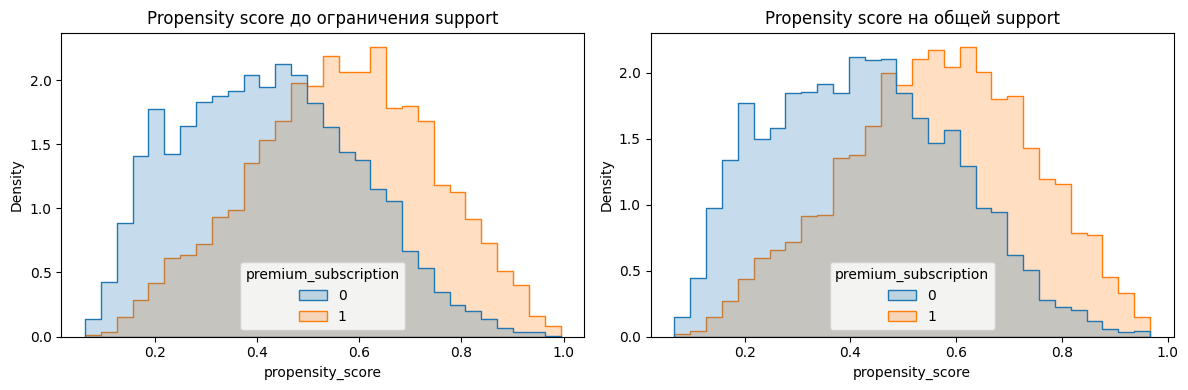

                           Оценка
нижняя граница support   0.067424
верхняя граница support  0.966202
доля на общей support    0.998600
caliper                  0.174789


In [16]:
psm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C = 1.0,
                                 penalty = 'l2',
                                 solver = 'lbfgs',
                                 fit_intercept = True,
                                 max_iter = 1000,
                                 random_state = 123))
])

propensity_score = psm_model.fit(features, np.ravel(target)).predict_proba(features)[:, 1]

df_psm = df.loc[:, controls + ['monthly_spending', 'premium_subscription']].copy()
df_psm['propensity_score'] = propensity_score

treated_mask = df_psm['premium_subscription'] == 1
control_mask = df_psm['premium_subscription'] == 0

ps_lower = max(df_psm.loc[treated_mask, 'propensity_score'].min(),
               df_psm.loc[control_mask, 'propensity_score'].min())
ps_upper = min(df_psm.loc[treated_mask, 'propensity_score'].max(),
               df_psm.loc[control_mask, 'propensity_score'].max())

common_support = df_psm['propensity_score'].between(ps_lower, ps_upper)
df_psm_common = df_psm.loc[common_support].reset_index(drop = True)

logit_ps = np.log(df_psm_common['propensity_score'].clip(1e-6, 1 - 1e-6) /
                  (1 - df_psm_common['propensity_score'].clip(1e-6, 1 - 1e-6)))
df_psm_common['logit_ps'] = logit_ps
caliper = 0.2 * np.std(df_psm_common['logit_ps'])

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
seaborn.histplot(data = df_psm,
                 x = 'propensity_score',
                 hue = 'premium_subscription',
                 bins = 30,
                 stat = 'density',
                 common_norm = False,
                 element = 'step',
                 ax = axes[0])
axes[0].set_title('Propensity score до ограничения support')

seaborn.histplot(data = df_psm_common,
                 x = 'propensity_score',
                 hue = 'premium_subscription',
                 bins = 30,
                 stat = 'density',
                 common_norm = False,
                 element = 'step',
                 ax = axes[1])
axes[1].set_title('Propensity score на общей support')
plt.tight_layout()
plt.show()

print(pd.DataFrame(data    = [ps_lower, ps_upper, common_support.mean(), caliper],
                   index   = ['нижняя граница support',
                              'верхняя граница support',
                              'доля на общей support',
                              'caliper'],
                   columns = ['Оценка']))


Для оценки `ATE` применим симметричное `nearest-neighbor matching` с возвращением: propensity score оценивается логистической регрессией, а matching и `caliper` считаются в одной шкале `logit propensity score`.

Для каждого клиента с подпиской подбирается ближайший клиент без подписки, а для каждого клиента без подписки — ближайший клиент с подпиской. После этого индивидуальные matched-разности усредняются по общей support. Такой вариант удобен тем, что он ориентирован именно на оценку среднего эффекта воздействия по всей рабочей выборке, а не только на `ATT`.

Идея общей support здесь принципиальна: сравнивать можно только те наблюдения, для которых в противоположной группе есть достаточно похожие аналоги по propensity score; само расстояние при matching считается по `logit_ps`.


In [17]:
treated_psm = df_psm_common.loc[df_psm_common['premium_subscription'] == 1].reset_index(drop = True)
control_psm = df_psm_common.loc[df_psm_common['premium_subscription'] == 0].reset_index(drop = True)

nn_control = NearestNeighbors(n_neighbors = 1)
nn_control.fit(control_psm[['logit_ps']])
dist_treated, idx_control = nn_control.kneighbors(treated_psm[['logit_ps']])
valid_treated = dist_treated[:, 0] <= caliper

nn_treated = NearestNeighbors(n_neighbors = 1)
nn_treated.fit(treated_psm[['logit_ps']])
dist_control, idx_treated = nn_treated.kneighbors(control_psm[['logit_ps']])
valid_control = dist_control[:, 0] <= caliper

tau_treated = (treated_psm.loc[valid_treated, 'monthly_spending'].to_numpy() -
               control_psm.iloc[idx_control[valid_treated, 0]]['monthly_spending'].to_numpy())
tau_control = (treated_psm.iloc[idx_treated[valid_control, 0]]['monthly_spending'].to_numpy() -
               control_psm.loc[valid_control, 'monthly_spending'].to_numpy())

ATE_PSM = np.mean(np.concatenate([tau_treated, tau_control]))
ATE_PSM_gap = ATE_PSM - ATE
ATE_PSM_abs_gap = np.abs(ATE_PSM_gap)

matched_treated = pd.concat([
    treated_psm.loc[valid_treated, controls].reset_index(drop = True),
    treated_psm.iloc[idx_treated[valid_control, 0]][controls].reset_index(drop = True)
], ignore_index = True)

matched_control = pd.concat([
    control_psm.iloc[idx_control[valid_treated, 0]][controls].reset_index(drop = True),
    control_psm.loc[valid_control, controls].reset_index(drop = True)
], ignore_index = True)

print(pd.DataFrame(data    = [valid_treated.sum(), valid_control.sum(), ATE_PSM, ATE_PSM_gap, ATE_PSM_abs_gap],
                   index   = ['matched treated',
                              'matched control',
                              'ATE PSM',
                              'PSM - true ATE',
                              '|PSM - true ATE|'],
                   columns = ['Оценка']))


                       Оценка
matched treated   4914.000000
matched control   5072.000000
ATE PSM           8019.055227
PSM - true ATE    1726.094753
|PSM - true ATE|  1726.094753


Проверим баланс контрольных переменных до и после matching с помощью `standardized mean differences`. Здесь `SMD before` считается не на всей исходной выборке, а на наблюдениях общей support до matching:

$$SMD(X_j) = \frac{\bar{X}_{1j} - \bar{X}_{0j}}{\sqrt{\frac{Var(X_{1j}) + Var(X_{0j})}{2}}}.$$

Именно так, как обсуждается в стандартной теории matching, после хорошего сопоставления абсолютные значения `SMD` должны уменьшаться и становиться близкими к нулю. В наших результатах это и происходит: по всем контрольным переменным баланс после matching заметно улучшается.

При этом сама `ATE PSM` оценка остается около `8019`, то есть все равно заметно выше истинного `ATE`. Следовательно, `PSM` хорошо выравнивает наблюдаемую часть различий между группами, но не может убрать смещение, вызванное ненаблюдаемой `online_preference`.


In [18]:
def smd(sample_treated, sample_control, columns):
    rows = []
    for col in columns:
        mean_t = sample_treated[col].mean()
        mean_c = sample_control[col].mean()
        var_t = sample_treated[col].var(ddof = 1)
        var_c = sample_control[col].var(ddof = 1)
        pooled_sd = np.sqrt((var_t + var_c) / 2)
        value = 0 if pooled_sd == 0 else (mean_t - mean_c) / pooled_sd
        rows.append(value)
    return pd.Series(rows, index = columns)

smd_before = smd(treated_psm[controls], control_psm[controls], controls)
smd_after = smd(matched_treated[controls], matched_control[controls], controls)

balance_table = pd.DataFrame({
    'SMD before': smd_before,
    'SMD after': smd_after,
    '|SMD before|': np.abs(smd_before),
    '|SMD after|': np.abs(smd_after)
})
print(balance_table)

ATE_table_best = pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls, ATE_T,
                                         ATE_dml_standard, ATE_IPW, ATE_DR, ATE_PSM],
                              index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE conditional means',
                                         'ATE dml standard', 'ATE IPW', 'ATE DR', 'ATE PSM'],
                              columns = ['Оценка'])
print('\nСравнение ATE с учетом PSM:')
print(ATE_table_best)


             SMD before  SMD after  |SMD before|  |SMD after|
income         0.455227  -0.009456      0.455227     0.009456
age           -0.273929  -0.006595      0.273929     0.006595
urban_area     0.458038   0.016607      0.458038     0.016607
family_size    0.288994  -0.015535      0.288994     0.015535

Сравнение ATE с учетом PSM:
                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7840.636281
ATE dml standard       7810.003445
ATE IPW                7816.842115
ATE DR                 7819.541881
ATE PSM                8019.055227


`Propensity Score Matching` хорошо подходит здесь как дополнительный метод оценки `ATE`, потому что он напрямую решает задачу сопоставления treated и control клиентов по наблюдаемым признакам. По сравнению с `IPW` метод обычно менее чувствителен к экстремальным весам, а по сравнению с `OLS` и `T-learner` делает акцент именно на сопоставимости групп. Слабая сторона `PSM` состоит в возможной потере наблюдений вне общей support и в том, что метод по-прежнему не устраняет смещение из-за ненаблюдаемой `online_preference`.

В наших данных `PSM` заметно улучшает баланс наблюдаемых признаков: абсолютные `SMD` после matching становятся очень малыми. Однако сама оценка `ATE PSM` равна примерно `8019`, то есть все равно заметно выше истинного `ATE = 6293`. Поэтому содержательный вывод такой: как дополнительный метод для пункта `5.4` `PSM` зашел хорошо, но полностью проблему эндогенности он не решает.

## 5.5

**Задание.** Оцените условные средние эффекты воздействия с помощью: метода наименьших квадратов; S-learner; T-learner; метода трансформации классов; X-learner. Сравните результаты и обсудите, насколько в вашем случае мотивированы применение метода X-learner. Опишите, как можно было бы использовать полученные вами оценки в бизнесе или при реализации государственных программ.

**Выполнение задания.**

Напомним, что условный средний эффект воздействия определяется как

$$CATE_i = E(monthly\_spending1_i \mid X_i) - E(monthly\_spending0_i \mid X_i).$$

CATE по МНК и T-learner уже были рассчитаны выше. Теперь оценим CATE с помощью S-learner: обучим одну модель на признаках и индикаторе подписки, а затем подставим каждому клиенту оба значения воздействия.

In [19]:
y = df.loc[:, ['monthly_spending']]
x = df.loc[:, controls + ['premium_subscription']]

rf2 = clone(best_regression)
rf2.fit(x, np.ravel(y))

x0 = deepcopy(x)
x0['premium_subscription'] = 0
monthly_spending0_rf2 = rf2.predict(x0)

x1 = deepcopy(x)
x1['premium_subscription'] = 1
monthly_spending1_rf2 = rf2.predict(x1)

CATE_S = monthly_spending1_rf2 - monthly_spending0_rf2
ATE_S = np.mean(CATE_S)


`S-learner` использует одну общую модель для обеих групп и восстанавливает эффект через разность двух counterfactual-прогнозов одной и той же функции. Это удобно, потому что вся выборка используется совместно, а сама процедура вычислительно проста.

Однако, как и подчеркивается в семинарской теории, при слабом сигнале воздействия или при очень разных структурных зависимостях в treated и control группах такой подход может сглаживать индивидуальные эффекты. Одна общая модель может слишком сильно усреднять поведение двух режимов и тем самым недооценивать или переоценивать heterogeneity.


Оценим CATE методом трансформации классов: модель обучается прогнозировать IPW-псевдоисход, который является шумной индивидуальной оценкой эффекта.

В этом подходе сначала строится псевдоисход

$$monthly\_spending_i^{*} = \frac{premium\_subscription_i \cdot monthly\_spending_i}{\hat{P}(premium\_subscription_i = 1 \mid X_i)} - \frac{(1-premium\_subscription_i) \cdot monthly\_spending_i}{1 - \hat{P}(premium\_subscription_i = 1 \mid X_i)},$$

а затем оценивается условное математическое ожидание

$$\widehat{CATE}^{CT}_i = \widehat{E}(monthly\_spending_i^{*} \mid X_i).$$

In [20]:
rf3 = clone(best_regression)
rf3.fit(features, monthly_spending_pseudo)
CATE_CT = rf3.predict(features)


Метод трансформации классов прост в реализации, потому что сводит задачу оценки `CATE` к обычной задаче регрессии на псевдоисход. Но цена этой простоты — высокая дисперсия.

В наших результатах это видно особенно хорошо: `CT` дает самый высокий `MSE0` среди рассмотренных `CATE`-методов. Это означает, что в данной задаче шум в `IPW`-псевдоисходах слишком велик, и модель хуже восстанавливает индивидуальную гетерогенность эффекта, чем `S-learner`, `X-learner` и даже `T-learner`.


Оценим CATE с помощью X-learner. Сначала строятся имитированные эффекты для treated и control групп, затем эти эффекты прогнозируются и объединяются с весами, связанными с вероятностью подписки.

Для клиентов с подпиской и без подписки строятся две вспомогательные величины:

$$D1_i = monthly\_spending_i - \widehat{E}(monthly\_spending0_i \mid X_i), \qquad premium\_subscription_i = 1,$$
$$D0_i = \widehat{E}(monthly\_spending1_i \mid X_i) - monthly\_spending_i, \qquad premium\_subscription_i = 0.$$

После этого оцениваются условные ожидания этих величин и объединяются в итоговую оценку

$$\widehat{CATE}^{X}_i = \hat{p}(X_i) \cdot \widehat{E}(D0_i \mid X_i) + (1-\hat{p}(X_i)) \cdot \widehat{E}(D1_i \mid X_i),$$

где $\hat{p}(X_i)$ — оцененная вероятность подписки.

In [21]:
rf4 = clone(best_regression)
rf5 = clone(best_regression)

D1 = monthly_spending[premium_subscription == 1] - monthly_spending0_rf[premium_subscription == 1]
D0 = monthly_spending1_rf[premium_subscription == 0] - monthly_spending[premium_subscription == 0]

rf4.fit(features[premium_subscription == 0], D0)
CATE_X0 = rf4.predict(features)

rf5.fit(features[premium_subscription == 1], D1)
CATE_X1 = rf5.predict(features)

CATE_X = prob_gb * CATE_X0 + (1 - prob_gb) * CATE_X1
ATE_X = np.mean(CATE_X)


`X-learner` особенно мотивирован в нашей задаче по двум причинам, как и в семинаре. Во-первых, сам эффект подписки гетерогенен. Во-вторых, treated и control группы различаются по составу, поэтому полезно отдельно использовать информацию о псевдоэффектах, получаемых внутри каждой группы.

Именно поэтому `X-learner` часто работает лучше в задачах, где есть структурная неоднородность и разная информативность двух подвыборок. В наших данных этот вывод подтверждается численно: по `MSE0` именно `X-learner` показывает наилучшее качество восстановления истинного `CATE`.


**Повышенная сложность. Выполнение задания.** В качестве дополнительного метода повышенной сложности оценим `CATE` с помощью `R-learner`. Идея метода состоит в том, чтобы сначала убрать из `monthly_spending` и `premium_subscription` часть, объясняемую наблюдаемыми признаками, а затем восстанавливать гетерогенный эффект по остаткам.

Базовое уравнение имеет вид

$$monthly\_spending_i - m(X_i) = \tau(X_i) \cdot (premium\_subscription_i - e(X_i)) + \varepsilon_i,$$

где $m(X_i) = E(monthly\_spending_i \mid X_i)$, $e(X_i) = P(premium\_subscription_i = 1 \mid X_i)$, а $\tau(X_i)$ — искомый условный эффект воздействия. Такой подход хорошо подходит здесь как дополнительный метод `CATE`, потому что он отдельно моделирует outcome и propensity score, а затем оценивает именно гетерогенный эффект.

In [22]:
mu_model = clone(best_regression)
mu_model.fit(features, monthly_spending)
mu_hat = mu_model.predict(features)

propensity_r = np.clip(prob_gb, 0.05, 0.95)
residual_y = monthly_spending - mu_hat
residual_t = premium_subscription - propensity_r

rlearner_mask = np.abs(residual_t) >= 0.05
pseudo_outcome_r = residual_y[rlearner_mask] / residual_t[rlearner_mask]
weights_r = residual_t[rlearner_mask] ** 2

tau_model = clone(best_regression)
tau_model.fit(features.loc[rlearner_mask, :], pseudo_outcome_r, sample_weight = weights_r)

CATE_R = tau_model.predict(features)
ATE_R = np.mean(CATE_R)

print(pd.DataFrame(data    = [rlearner_mask.mean(), ATE_R, ATE_R - ATE, np.mean(CATE_R - CATE)],
                   index   = ['share kept after trimming',
                              'mean R-learner CATE',
                              'mean R-learner CATE - true ATE',
                              'mean individual bias'],
                   columns = ['Оценка']))


                                     Оценка
share kept after trimming          1.000000
mean R-learner CATE             7582.083415
mean R-learner CATE - true ATE  1289.122940
mean individual bias            1293.642259


В `R-learner` мы используем residualization-подход: сначала оцениваем `m(X)` и `e(X)`, затем переходим к остаткам исхода и воздействия. Это упрощенная реализация `R-learner` без cross-fitting, поэтому возможна зависимость от качества nuisance-моделей и переобучения.

Фактически оценивается уравнение

$$monthly\_spending_i - \hat{m}(X_i) \approx \tau(X_i) \cdot (premium\_subscription_i - \hat{e}(X_i)).$$

Небольшой `trimming` по наблюдениям с почти нулевым остатком воздействия нужен для численной устойчивости. Если величина $premium\_subscription_i - \hat{e}(X_i)$ слишком мала, то псевдоисход становится нестабильным и может искусственно увеличивать дисперсию оценки `CATE`.


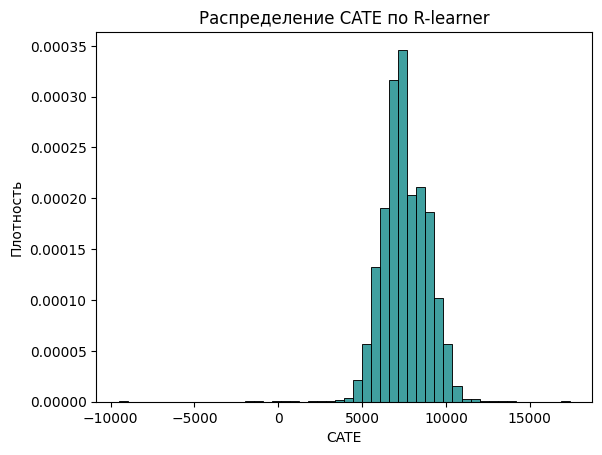

In [23]:
seaborn.histplot(CATE_R, stat = 'density', bins = 50, color = 'teal')
plt.xlabel('CATE')
plt.ylabel('Плотность')
plt.title('Распределение CATE по R-learner')
plt.show()


`R-learner` занимает промежуточное место между уже использованными подходами. По сравнению с `S-learner` он меньше зависит от того, насколько одна общая модель умеет различать treatment heterogeneity. По сравнению с `T-learner` он эффективнее использует общую информацию о вероятности подписки и среднем уровне исхода. По сравнению с методом трансформации классов `R-learner` обычно устойчивее, потому что не строится напрямую только на шумном `IPW`-псевдоисходе. По сравнению с `X-learner` его плюс в явной residualization-логике, а минус в чувствительности к качеству nuisance-моделей $m(X)$ и $e(X)$.

На наших данных `R-learner` дает средний `CATE ≈ 7582`, то есть по среднему уровню он ближе к истинному `ATE`, чем остальные CATE-методы. По `RMSE` он почти совпадает с `X-learner` и немного лучше `S-learner`, но по корреляции с истинным `CATE` уступает `X-learner`, `S-learner` и МНК. Значит, как дополнительный метод повышенной сложности `R-learner` здесь сработал содержательно корректно, но не является однозначно лучшим по всем критериям индивидуальной гетерогенности.

Сравним `CATE`-оценки с истинными значениями, доступными в симуляции. Это ключевое преимущество учебной постановки: в реальных данных истинный `CATE_i` недоступен, а здесь мы можем напрямую измерить качество восстановления гетерогенности.

Поэтому далее удобно смотреть не только на отдельные примеры предсказаний, но и на интегральные критерии качества по всей выборке.


In [24]:
CATE_mat = pd.DataFrame({'True': CATE,
                         'LS': CATE_ls,
                         'T-learner': CATE_T,
                         'S-learner': CATE_S,
                         'CT': CATE_CT,
                         'X-learner': CATE_X,
                         'R-learner': CATE_R})
print(CATE_mat)


              True            LS     T-learner     S-learner            CT  \
0      3220.164759   8335.132257   8477.851643   8480.975092   7885.468158   
1      2808.381400   7624.997365   7208.825283   6995.210109   5078.734728   
2      8765.498854  13961.435774  11554.645841  11273.832281  22620.501303   
3      4648.778373   8354.435162   8041.071252   7685.057718   6342.301932   
4       154.257823   5394.738764   5783.296852   6736.238337   2658.218805   
...            ...           ...           ...           ...           ...   
9995   6286.950626  10105.710376   8922.728382   9365.523558   8948.068417   
9996   8147.934355   8234.310692   8412.893156   7621.888936  11166.427360   
9997   5995.806435   8626.845712   8210.365036   7939.564629   7659.047337   
9998  10821.258881  10707.583778  10824.888367   9657.439799   5639.696568   
9999   7606.856302   9383.460097   9560.666030   8788.044172  10139.787318   

         X-learner    R-learner  
0      8061.185321  7787.5347

Таблица показывает индивидуальные оценки `CATE` для каждого метода. Для качества сравнения, как и в семинаре, удобно использовать среднеквадратичную ошибку относительно истинного `CATE`:

$$MSE_0 = \frac{1}{n}\sum\limits_{i=1}^{n}(CATE_i - \widehat{CATE}_i)^2.$$

Кроме того, полезно смотреть на

$$RMSE = \sqrt{MSE_0}, \qquad MAE = \frac{1}{n}\sum\limits_{i=1}^{n}|CATE_i - \widehat{CATE}_i|,$$

а также на среднее значение предсказанного `CATE`, его смещение относительно истинного среднего эффекта и корреляцию с истинным `CATE`. Такой набор метрик позволяет разделить два вопроса: насколько хорошо метод восстанавливает средний уровень эффекта и насколько хорошо он ранжирует клиентов по индивидуальной гетерогенности.


In [25]:
CATE_quality = pd.DataFrame({
    'mean CATE': [np.mean(CATE_ls), np.mean(CATE_T), np.mean(CATE_S), np.mean(CATE_CT), np.mean(CATE_X), np.mean(CATE_R)],
    'bias mean': [np.mean(CATE_ls) - ATE, np.mean(CATE_T) - ATE, np.mean(CATE_S) - ATE,
                  np.mean(CATE_CT) - ATE, np.mean(CATE_X) - ATE, np.mean(CATE_R) - ATE],
    'RMSE': [np.sqrt(np.mean((CATE_ls - CATE) ** 2)), np.sqrt(np.mean((CATE_T - CATE) ** 2)),
             np.sqrt(np.mean((CATE_S - CATE) ** 2)), np.sqrt(np.mean((CATE_CT - CATE) ** 2)),
             np.sqrt(np.mean((CATE_X - CATE) ** 2)), np.sqrt(np.mean((CATE_R - CATE) ** 2))],
    'MAE': [np.mean(np.abs(CATE_ls - CATE)), np.mean(np.abs(CATE_T - CATE)),
            np.mean(np.abs(CATE_S - CATE)), np.mean(np.abs(CATE_CT - CATE)),
            np.mean(np.abs(CATE_X - CATE)), np.mean(np.abs(CATE_R - CATE))],
    'corr with true CATE': [np.corrcoef(CATE_ls, CATE)[0, 1], np.corrcoef(CATE_T, CATE)[0, 1],
                             np.corrcoef(CATE_S, CATE)[0, 1], np.corrcoef(CATE_CT, CATE)[0, 1],
                             np.corrcoef(CATE_X, CATE)[0, 1], np.corrcoef(CATE_R, CATE)[0, 1]]
}, index = ['LS', 'T-learner', 'S-learner', 'CT', 'X-learner', 'R-learner'])

CATE_MSE0 = pd.DataFrame({'MSE0': CATE_quality['RMSE'] ** 2})
print(CATE_quality)


             mean CATE    bias mean         RMSE          MAE  \
LS         8034.566740  1741.606266  2588.920971  2119.934038   
T-learner  7840.636281  1547.675807  2503.455504  2023.760299   
S-learner  7785.133587  1492.173112  2450.863404  1989.368169   
CT         7816.842115  1523.881640  3691.492248  2529.430633   
X-learner  7751.172886  1458.212411  2429.073810  1966.267175   
R-learner  7582.083415  1289.122940  2431.147547  1943.286888   

           corr with true CATE  
LS                    0.617022  
T-learner             0.587971  
S-learner             0.604093  
CT                    0.409563  
X-learner             0.605293  
R-learner             0.529921  


По нашим метрикам лучше всего гетерогенность эффекта по `MSE0` восстанавливает `X-learner`: у него минимальный `MSE0 ≈ 5.90 \cdot 10^6` и наименьший `RMSE` среди рассматриваемых методов. `R-learner` идет практически рядом по `RMSE` и имеет меньший `MAE`, а `S-learner` также показывает сильный результат. Метод трансформации классов заметно хуже по `MSE0` из-за высокой дисперсии IPW-псевдоисходов.

Содержательно это означает, что для задач, где важна точность индивидуальной величины эффекта, `X-learner` в этой симуляции выглядит наиболее убедительно по основной MSE-метрике. Если же акцент делать именно на ранжировке клиентов, нужно также смотреть на корреляцию с истинным `CATE`: по ней лучшим оказывается МНК, а `X-learner` и `S-learner` идут близко. Такие оценки можно использовать, например, для показа премиум-офера тем клиентам, у которых предсказанный прирост трат максимален, но решение лучше проверять по нескольким метрикам одновременно.

**Примечание.** Oracle-CATE = g1 − g0 включает вариацию ненаблюдаемой `online_preference`, поэтому абсолютные значения MSE0 содержат irreducible variance, одинаковую для всех методов; ранжирование методов остаётся корректным, но абсолютные MSE0 завышены примерно на 25–35%.

Дополнительно сравним CATE-оценки с IPW-псевдоисходами. Этот критерий более шумный, но показывает, насколько методы близки к псевдоиндивидуальным эффектам, построенным только на наблюдаемых данных.

Соответствующий критерий имеет вид:

$$MSE_1 = \frac{1}{n}\sum\limits_{i=1}^{n}(monthly\_spending_i^{*} - \widehat{CATE}_i)^2.$$

In [26]:
CATE_MSE1 = pd.DataFrame(data    = [np.mean((monthly_spending_pseudo - CATE_ls) ** 2),
                                    np.mean((monthly_spending_pseudo - CATE_T) ** 2),
                                    np.mean((monthly_spending_pseudo - CATE_S) ** 2),
                                    np.mean((monthly_spending_pseudo - CATE_CT) ** 2),
                                    np.mean((monthly_spending_pseudo - CATE_X) ** 2),
                                    np.mean((monthly_spending_pseudo - CATE_R) ** 2)],
                         index   = ['LS', 'T-learner', 'S-learner', 'CT', 'X-learner', 'R-learner'],
                         columns = ['MSE1'])
print(CATE_MSE1)


                   MSE1
LS         5.089652e+08
T-learner  5.072717e+08
S-learner  5.092096e+08
CT         4.783526e+08
X-learner  5.084929e+08
R-learner  5.075149e+08


Значения `MSE1` по псевдоисходам существенно больше, потому что сами `IPW`-псевдоисходы имеют высокую дисперсию. Поэтому, как и в семинаре, основной содержательный критерий здесь — это сравнение с истинным `CATE`, а не только с шумной proxy-целью.

В нашем случае по `MSE1` минимальное значение получается у метода трансформации классов, потому что он напрямую обучается на том же IPW-псевдоисходе. Но это не означает, что он лучше восстанавливает истинный `CATE`: по `MSE0` относительно симуляционного oracle-CATE метод `CT` оказывается худшим. Поэтому главный вывод делаем по `MSE0`, а `MSE1` используем только как дополнительную диагностику близости к шумной proxy-цели.

## 5.6

**Задание.** Оцените локальный средний эффект воздействия с помощью: двойного машинного обучения без инструментальной переменной; двойного машинного обучения с инструментальной переменной. Сопоставьте результаты и объясните, в чем в вашем случае будет заключаться различие между средним эффектом воздействия и локальным средним эффектом воздействия. Приведите содержательную экономическую интерпретацию оценки локального среднего эффекта воздействия.

**Выполнение задания.**

Как и в семинаре, здесь важно отделить проблему `ATE` от проблемы `LATE`. При наличии эндогенности без инструмента можно пытаться оценивать `ATE` только при очень сильной предпосылке условной независимости. Если же эта предпосылка нарушена, то инструментальный подход позволяет идентифицировать не средний эффект для всех клиентов, а локальный средний эффект для соблюдателей.

Сначала построим `DML` без инструмента. Технически это `DoubleMLIRM`, поэтому он оценивает `ATE` при условной независимости, а не полноценный `LATE`. Мы оставляем его как бенчмарк без использования инструментальной переменной, чтобы затем увидеть, насколько меняется результат после учета инструментальной структуры.


Перед DML-оценками зафиксируем важную техническую деталь сравнения. Истинные `ATE` и `LATE` выше рассчитаны на полной выборке из 30000 наблюдений, а DML-оценки ниже строятся на рабочей подвыборке из 10000 наблюдений. Поэтому в таблицах дальше full-sample эффекты остаются главным эталоном DGP, но для контроля также выводим oracle-эффекты на самой рабочей подвыборке.


In [27]:
ATE_sample_oracle = np.mean(TE)
LATE_sample_oracle = np.mean(TE[compliers])
ATET_sample_oracle = np.mean(TE[premium_subscription == 1])

oracle_sample_table = pd.DataFrame({
    'полная выборка 30000': [ATE, LATE, ATET],
    'рабочая подвыборка 10000': [ATE_sample_oracle, LATE_sample_oracle, ATET_sample_oracle]
}, index = ['ATE oracle', 'LATE oracle', 'ATET oracle'])
print(oracle_sample_table)


             полная выборка 30000  рабочая подвыборка 10000
ATE oracle            6292.960475               6324.949892
LATE oracle           6280.319157               6328.988711
ATET oracle           7274.638232               7285.158323


In [28]:
dml_no_iv_data = dml.DoubleMLData(data   = df,
                                  y_col  = 'monthly_spending',
                                  d_cols = 'premium_subscription',
                                  x_cols = controls)

np.random.seed(123)
dml_no_iv = dml.DoubleMLIRM(obj_dml_data = dml_no_iv_data,
                            ml_g         = g_Y,
                            ml_m         = g_T,
                            n_rep        = 1,
                            n_folds      = 5)

dml_no_iv.fit()
ATE_dml_no_iv = dml_no_iv.coef[0]
print(dml_no_iv)


================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: monthly_spending
Treatment variable(s): ['premium_subscription']
Covariates: ['income', 'age', 'urban_area', 'family_size']
Instrument variable(s): None
No. Observations: 10000

------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: GradientBoostingRegressor(n_estimators=120, random_state=123)
Learner ml_m: GradientBoostingClassifier(max_depth=2, random_state=123)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[2236.91954694]]
Learner ml_g1 RMSE: [[4115.61462301]]
Classification:
Learner ml_m Log Loss: [[0.5880917]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
                             coef    std err           t  P>|t|        2.5 %  \
prem

Оценка без инструмента показывает, что будет получено, если игнорировать инструментальную структуру и опираться только на наблюдаемые признаки. В нашем случае это дает число `≈ 7810`, которое заметно выше как full-sample oracle `LATE = 6280`, так и sample oracle `LATE ≈ 6329`.

Следовательно, если не учитывать эндогенность подписки и не использовать инструмент, оценка эффекта для клиентов оказывается завышенной. Это ровно та проблема, ради которой в следующем шаге и нужен `IV-DML`.

**Выполнение задания.** Теперь используем `DoubleMLIIVM`, где `free_trial_banner` выступает инструментом для премиум-подписки. Эта модель оценивает `LATE` для соблюдателей.

В инструментальном подходе `DoubleMLIIVM` используются три nuisance-объекта:

$$g(Z_i, X_i) = E(monthly\_spending_i \mid X_i, free\_trial\_banner_i = Z_i),$$
$$m(X_i) = P(free\_trial\_banner_i = 1 \mid X_i),$$
$$r(Z_i, X_i) = P(premium\_subscription_i = 1 \mid X_i, free\_trial\_banner_i = Z_i).$$

При выполнении условий релевантности, экзогенности и монотонности инструмента `DoubleMLIIVM` оценивает именно локальный средний эффект воздействия. Иными словами, он отвечает на вопрос: каков эффект подписки для тех клиентов, чье решение о подписке действительно меняется из-за баннера.


Перед оценкой `IV-DML` проверим first stage и состав типов клиентов. Баннер должен заметно менять вероятность подписки, а соблюдатели должны иметь ненулевую долю; это поддерживает релевантность инструмента и содержательную интерпретацию `LATE`. Доли типов клиентов (`Complier`, `Always taker`, `Never taker`) являются oracle-диагностикой из симуляционной DGP: в реальных данных они напрямую не наблюдаются. Observed first-stage difference может не совпадать с oracle-долей compliers, потому что сравнение `P(D=1|Z=1)-P(D=1|Z=0)` считается по фактически получившим и не получившим баннер на конечной подвыборке, где состав групп по `X` может отличаться.


In [29]:
first_stage_by_z = df.groupby('free_trial_banner')['premium_subscription'].mean()
type_shares = df['ind_type'].value_counts(normalize = True).reindex(['Never taker', 'Complier', 'Always taker'], fill_value = 0)

first_stage_table = pd.DataFrame({
    'Оценка': [first_stage_by_z.loc[0],
               first_stage_by_z.loc[1],
               first_stage_by_z.loc[1] - first_stage_by_z.loc[0],
               type_shares.loc['Complier'],
               type_shares.loc['Always taker'],
               type_shares.loc['Never taker']]
}, index = ['P(D=1 | Z=0)',
            'P(D=1 | Z=1)',
            'first-stage difference',
            'share Complier',
            'share Always Taker',
            'share Never Taker'])
print(first_stage_table)


                          Оценка
P(D=1 | Z=0)            0.410812
P(D=1 | Z=1)            0.647740
first-stage difference  0.236928
share Complier          0.162400
share Always Taker      0.437500
share Never Taker       0.400100


In [30]:
dml_iv_data = dml.DoubleMLData(data   = df,
                               y_col  = 'monthly_spending',
                               d_cols = 'premium_subscription',
                               z_cols = 'free_trial_banner',
                               x_cols = controls)

g_Z = GradientBoostingClassifier(loss          = 'log_loss',
                                 n_estimators  = 100,
                                 learning_rate = 0.1,
                                 random_state  = 123)

np.random.seed(123)
dml_iv = dml.DoubleMLIIVM(obj_dml_data = dml_iv_data,
                          ml_g         = g_Y,
                          ml_m         = g_Z,
                          ml_r         = g_T,
                          n_rep        = 1,
                          n_folds      = 5)

dml_iv.fit()
LATE_dml_iv = dml_iv.coef[0]
print(dml_iv)


================== DoubleMLIIVM Object ==================

------------------ Data Summary      ------------------
Outcome variable: monthly_spending
Treatment variable(s): ['premium_subscription']
Covariates: ['income', 'age', 'urban_area', 'family_size']
Instrument variable(s): ['free_trial_banner']
No. Observations: 10000

------------------ Score & Algorithm ------------------
Score function: LATE

------------------ Machine Learner   ------------------
Learner ml_g: GradientBoostingRegressor(n_estimators=120, random_state=123)
Learner ml_m: GradientBoostingClassifier(random_state=123)
Learner ml_r: GradientBoostingClassifier(max_depth=2, random_state=123)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[4745.69023845]]
Learner ml_g1 RMSE: [[4938.0615393]]
Classification:
Learner ml_m Log Loss: [[0.52915578]]
Learner ml_r0 Log Loss: [[0.58673924]]
Learner ml_r1 Log Loss: [[0.5665024]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sam

`IV-DML` оценивает эффект не для всех клиентов, а для соблюдателей, то есть для той подгруппы, чье решение о подписке изменяется под воздействием баннера. В наших данных оценка `LATE dml IV` равна примерно `6250`. По сравнению с full-sample oracle `LATE = 6280` абсолютное отклонение составляет около `30`; по сравнению с sample oracle `LATE ≈ 6329` отклонение составляет около `79`.

Оба сравнения намного лучше бенчмарка без инструмента (`≈ 1530` относительно full-sample `LATE` и `≈ 1481` относительно sample `LATE`). Значит, именно введение инструмента радикально улучшает качество оценки локального эффекта. Экономически это означает, что баннер позволяет выделить клиентов, для которых подписка действительно является маржинальным решением, и именно для них эффект подписки можно оценить особенно содержательно.

**Повышенная сложность. Выполнение задания.** Поскольку `Rscript` и пакет `switchSelection` в текущей среде недоступны, оценим параметрический benchmark без R: two-step endogenous switching model в Python. Это не полноценная реализация `switchSelection`/FIML и ниже не оцениваются стандартные ошибки switching-модели, поэтому результат используется именно как параметрическая точка сравнения.

На первом шаге оценивается параметрическое selection equation через probit:

$$premium\_subscription_i^{*} = \alpha_0 + \alpha_1 free\_trial\_banner_i + X_i'\alpha + u_i, \qquad premium\_subscription_i = 1[premium\_subscription_i^{*} > 0].$$

На втором шаге отдельно для клиентов с подпиской и без подписки оцениваются outcome-equations с поправкой Хекмана через inverse Mills ratio:

$$monthly\_spending_i = X_i'\beta_1 + \rho_1\sigma_1\lambda_1(X_i,Z_i) + \varepsilon_{1i}, \qquad D_i=1,$$

$$monthly\_spending_i = X_i'\beta_0 + \rho_0\sigma_0\lambda_0(X_i,Z_i) + \varepsilon_{0i}, \qquad D_i=0.$$

Это параметрический подход: и модель выбора режима, и модели исходов задаются явной функциональной формой. По сравнению с `IV-DML` он лучше интерпретируется, но сильнее зависит от корректности probit-спецификации и линейных outcome-equations.

In [31]:
selection_x = sm.add_constant(df.loc[:, ['free_trial_banner'] + controls])
selection_model = sm.Probit(df['premium_subscription'], selection_x).fit(disp = False)
selection_index = np.asarray(selection_model.predict(selection_x, which = "linear"))
selection_prob = np.clip(np.asarray(selection_model.predict(selection_x)), 1e-6, 1 - 1e-6)

mills_treated = norm.pdf(selection_index) / selection_prob
mills_control = -norm.pdf(selection_index) / (1 - selection_prob)

outcome_x = sm.add_constant(df.loc[:, controls])
outcome_treated_x = outcome_x.loc[premium_subscription == 1].copy()
outcome_control_x = outcome_x.loc[premium_subscription == 0].copy()
outcome_treated_x['mills'] = mills_treated[premium_subscription == 1]
outcome_control_x['mills'] = mills_control[premium_subscription == 0]

switch_y1_model = sm.OLS(df.loc[premium_subscription == 1, 'monthly_spending'], outcome_treated_x).fit()
switch_y0_model = sm.OLS(df.loc[premium_subscription == 0, 'monthly_spending'], outcome_control_x).fit()

outcome_all_treated = outcome_x.copy()
outcome_all_control = outcome_x.copy()
outcome_all_treated['mills'] = mills_treated
outcome_all_control['mills'] = mills_control

monthly_spending1_switch = np.asarray(switch_y1_model.predict(outcome_all_treated))
monthly_spending0_switch = np.asarray(switch_y0_model.predict(outcome_all_control))
tau_switch = monthly_spending1_switch - monthly_spending0_switch

selection_z1 = selection_x.copy()
selection_z0 = selection_x.copy()
selection_z1['free_trial_banner'] = 1
selection_z0['free_trial_banner'] = 0
p_t1_z1 = np.clip(np.asarray(selection_model.predict(selection_z1)), 1e-6, 1 - 1e-6)
p_t1_z0 = np.clip(np.asarray(selection_model.predict(selection_z0)), 1e-6, 1 - 1e-6)
complier_weight_raw = p_t1_z1 - p_t1_z0
complier_weight = np.clip(complier_weight_raw, a_min = 0, a_max = None)

weight_mask = complier_weight > 1e-6
LATE_switch = np.average(tau_switch[weight_mask], weights = complier_weight[weight_mask])
LATE_switch_abs_gap = np.abs(LATE_switch - LATE)

switch_diagnostics = pd.DataFrame(data    = [
                                    np.mean(complier_weight_raw < 0),
                                    np.mean(complier_weight <= 1e-6),
                                    np.mean(complier_weight_raw),
                                    np.mean(complier_weight),
                                    np.sum(complier_weight),
                                    LATE_switch,
                                    LATE_switch_abs_gap],
                                 index   = ['share negative raw complier weights',
                                            'share clipped or near-zero weights',
                                            'mean raw complier weight',
                                            'mean clipped complier weight',
                                            'sum clipped complier weights',
                                            'LATE parametric switching',
                                            '|parametric switching - true LATE|'],
                                 columns = ['Оценка'])
print(switch_diagnostics)

                                          Оценка
share negative raw complier weights     0.000000
share clipped or near-zero weights      0.000000
mean raw complier weight                0.160194
mean clipped complier weight            0.160194
sum clipped complier weights         1601.938869
LATE parametric switching            8027.336694
|parametric switching - true LATE|   1747.017537


По параметрической switching-модели получаем предсказанные потенциальные исходы $\widehat{monthly\_spending1}_i$ и $\widehat{monthly\_spending0}_i$, а затем индивидуальный параметрический эффект

$$\widehat{\tau}_i = \widehat{monthly\_spending1}_i - \widehat{monthly\_spending0}_i.$$

Чтобы приблизиться именно к локальному эффекту для соблюдателей, используем параметрические complier weights:

$$\widehat{c}_i = \widehat{P}(premium\_subscription_i = 1 \mid free\_trial\_banner_i = 1, X_i) - \widehat{P}(premium\_subscription_i = 1 \mid free\_trial\_banner_i = 0, X_i).$$

Тогда итоговая параметрическая оценка имеет вид

$$\widehat{LATE}^{param} = \frac{\sum_i \widehat{c}_i \widehat{\tau}_i}{\sum_i \widehat{c}_i}.$$

Если из-за численных ошибок некоторые веса оказываются отрицательными, мы клиппируем их к нулю. Такая процедура делает интерпретацию весов как вероятностной меры принадлежности к соблюдателям более устойчивой.

In [32]:
LATE_table = pd.DataFrame({
    'Оценка': [ATE, LATE, ATE_dml_no_iv, LATE_dml_iv, LATE_switch],
    '|estimate - true LATE|': [np.abs(ATE - LATE), 0, np.abs(ATE_dml_no_iv - LATE),
                              np.abs(LATE_dml_iv - LATE), LATE_switch_abs_gap]
}, index = ['ATE', 'LATE', 'ATE dml no IV', 'LATE dml IV', 'LATE parametric switching'])
print(LATE_table)

                                Оценка  |estimate - true LATE|
ATE                        6292.960475               12.641317
LATE                       6280.319157                0.000000
ATE dml no IV              7810.003445             1529.684288
LATE dml IV                6250.160365               30.158792
LATE parametric switching  8027.336694             1747.017537


`ATE` относится ко всем клиентам, а `LATE` — только к соблюдателям. В данном исследовании `LATE` показывает эффект премиум-подписки для клиентов, которых можно подтолкнуть к подписке показом баннера.

Параметрический switching benchmark дает оценку того же локального эффекта через жесткую функциональную форму: probit для выбора подписки и две линейные outcome-модели с поправкой на selection. В отличие от `IV-DML`, этот подход менее гибкий и чувствителен к спецификации, зато его легче интерпретировать как явную структурную модель выбора режима и исходов. Поскольку это ручная two-step-реализация без стандартных ошибок и без полноценного `switchSelection`, результат следует использовать только как иллюстративный параметрический benchmark, а не как надежную финальную оценку. Большое отклонение от oracle `LATE` показывает, что в этой DGP линейная switching-спецификация недостаточно хорошо приближает истинный механизм.

## 5.7

**Задание.** Оцените средние эффекты воздействия и локальные средние эффекты воздействия используя худшие из обученных классификационных и регрессионных моделей. Сопоставьте результаты с теми, что были получены с помощью лучших моделей. Сдеайте вывод об устойчивости результатов к качеству используемых методов машинного обучения.

**Выполнение задания.**

В этом пункте, как и в семинаре, сохраняются те же формулы для `T-learner`, `IPW`, `DR`, `DML` и `IV-DML`, но nuisance-модели заменяются худшими по качеству из предыдущих разделов.

Худший классификатор определён в разделе 3 программно по минимальному `AUC` на тестовой выборке (`worst_model`), худшая регрессионная модель — в разделе 4 по максимальному `RMSE` на тестовой выборке (`worst_regressor_all`). Модели переиспользуются здесь через `clone()` и переобучаются на causal controls без `free_trial_banner`.

Такая замена позволяет проверить, насколько чувствительны оценки `ATE` и `LATE` к ошибкам прогнозирования условных средних и вероятностей. Если метод устойчив, то замена лучших моделей на худшие не должна полностью менять качественный вывод. Если же оценка резко меняется, это означает сильную зависимость итогового causal-вывода от качества вспомогательных ML-моделей.

In [33]:
worst_classification = clone(all_classification_models[worst_model])
worst_classification.fit(features, np.ravel(target))

worst_regression = clone(worst_regressor_all)
worst_regression.fit(features, np.ravel(y))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Повторим T-learner, IPW, DR, DML и IV-DML с худшими nuisance-моделями. Для IPW/DR отдельно проверяем диапазон propensity score: если вероятность близка к 0 или 1, веса становятся большими и оценки могут быть нестабильными.

In [34]:
rf = clone(worst_regression)

x0_worst = df.loc[premium_subscription == 0, controls]
x1_worst = df.loc[premium_subscription == 1, controls]
x_worst  = df.loc[:, controls]

rf.fit(x0_worst, np.ravel(y0))
monthly_spending0_worst = rf.predict(x_worst)

rf.fit(x1_worst, np.ravel(y1))
monthly_spending1_worst = rf.predict(x_worst)

CATE_T_worst = monthly_spending1_worst - monthly_spending0_worst
ATE_T_worst = np.mean(CATE_T_worst)
ATE_ls_worst = np.mean(monthly_spending1_worst - monthly_spending0_worst)

gb = clone(worst_classification)
gb.fit(features, np.ravel(target))
prob_gb_worst = gb.predict_proba(features)[:, 1]
print(pd.DataFrame(data    = [np.min(prob_gb_worst), np.max(prob_gb_worst)],
                   index   = ['worst min prob', 'worst max prob'],
                   columns = ['Оценка']))

monthly_spending_pseudo_worst = ((monthly_spending * premium_subscription) / prob_gb_worst -
                                 (monthly_spending * (1 - premium_subscription)) / (1 - prob_gb_worst))
ATE_IPW_worst = np.mean(monthly_spending_pseudo_worst)

ATE_DR_worst = np.mean((monthly_spending1_worst - monthly_spending0_worst) +
                       premium_subscription * (monthly_spending - monthly_spending1_worst) / prob_gb_worst -
                       (1 - premium_subscription) * (monthly_spending - monthly_spending0_worst) / (1 - prob_gb_worst))


                  Оценка
worst min prob  0.064493
worst max prob  0.993688


Для DML-оценок отдельно создадим объекты `DoubleMLData` и применим худшие модели как nuisance-оценки.

In [35]:
dml_worst_data = dml.DoubleMLData(data   = df,
                                  y_col  = 'monthly_spending',
                                  d_cols = 'premium_subscription',
                                  x_cols = controls)

g_Y_worst = clone(worst_regression)
g_T_worst = clone(worst_classification)

np.random.seed(123)
dml_worst = dml.DoubleMLIRM(obj_dml_data = dml_worst_data,
                            ml_g         = g_Y_worst,
                            ml_m         = g_T_worst,
                            n_rep        = 1,
                            n_folds      = 5)

dml_worst.fit()
ATE_dml_worst = dml_worst.coef[0]

dml_iv_worst_data = dml.DoubleMLData(data   = df,
                                     y_col  = 'monthly_spending',
                                     d_cols = 'premium_subscription',
                                     z_cols = 'free_trial_banner',
                                     x_cols = controls)

g_Z_worst = clone(worst_classification)

np.random.seed(123)
dml_iv_worst = dml.DoubleMLIIVM(obj_dml_data = dml_iv_worst_data,
                                ml_g         = g_Y_worst,
                                ml_m         = g_Z_worst,
                                ml_r         = g_T_worst,
                                n_rep        = 1,
                                n_folds      = 5)

dml_iv_worst.fit()
LATE_dml_iv_worst = dml_iv_worst.coef[0]


Сопоставим оценки, полученные лучшими и худшими моделями. Это позволяет отделить два уровня неопределенности: собственно эконометрическую идентификацию и качество статистического приближения nuisance-объектов.

В наших результатах `ATE`-оценки при переходе к худшим моделям в целом сдвигаются вверх, а инструментальная `LATE DML IV` меняется особенно заметно: примерно с `6250` до `8091`. Следовательно, `IV-DML` особенно чувствителен к качеству вспомогательных моделей, потому что в нем одновременно участвуют outcome-model, treatment-model и instrument-model.

In [36]:
stability_table = pd.DataFrame({
    'лучшие модели': [ATE_ls, ATE_T, ATE_IPW, ATE_DR, ATE_dml_standard, LATE_dml_iv],
    'худшие модели': [ATE_ls_worst, ATE_T_worst, ATE_IPW_worst, ATE_DR_worst, ATE_dml_worst, LATE_dml_iv_worst]
}, index = ['ATE ls', 'ATE conditional means', 'ATE IPW', 'ATE DR', 'ATE DML', 'LATE DML IV'])
print(stability_table)


                       лучшие модели  худшие модели
ATE ls                   8034.566740    8034.566740
ATE conditional means    7840.636281    8034.566740
ATE IPW                  7816.842115    7914.957750
ATE DR                   7819.541881    8065.177121
ATE DML                  7810.003445    8064.232320
LATE DML IV              6250.160365    8450.271156


Оценки ATE заметно меняются при переходе к худшим nuisance-моделям, что говорит о чувствительности результатов к качеству прогнозных моделей. Строка `ATE ls` не меняется, потому что худшая регрессионная модель и есть линейная регрессия/МНК, то есть тот же estimator, который используется в LS-бенчмарке. У худшего propensity максимальная вероятность близка к 1 (`0.992`), поэтому IPW/DR с худшими моделями потенциально менее устойчивы из-за больших обратных весов. Для LATE через IV-DML различие также может быть существенным, потому что инструментальная модель требует одновременно хороших моделей исхода, воздействия и инструмента.

## 5.8

**Задание.** Резюмируйте ключевые выводы проведенного в данном разделе анализа.

**Выполнение задания.**

Соберем итоговые таблицы раздела, а затем содержательно интерпретируем их с точки зрения `ATE`, `CATE`, `LATE` и устойчивости методов.


In [37]:
print('ATE:')
print(ATE_table_best)
print('\nCATE MSE:')
print(CATE_MSE0)
print('\nLATE:')
print(LATE_table)
print('\nУстойчивость:')
print(stability_table)


ATE:
                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7840.636281
ATE dml standard       7810.003445
ATE IPW                7816.842115
ATE DR                 7819.541881
ATE PSM                8019.055227

CATE MSE:
                   MSE0
LS         6.702512e+06
T-learner  6.267289e+06
S-learner  6.006731e+06
CT         1.362712e+07
X-learner  5.900400e+06
R-learner  5.910478e+06

LATE:
                                Оценка  |estimate - true LATE|
ATE                        6292.960475               12.641317
LATE                       6280.319157                0.000000
ATE dml no IV              7810.003445             1529.684288
LATE dml IV                6250.160365               30.158792
LATE parametric switching  8027.336694             1747.017537

Устойчивость:
                       лучшие модели  худшие модели
ATE ls                   8034.566740    8034.5667

Проведенный анализ дает несколько важных выводов.

Во-первых, премиум-подписка оказывает положительный причинный эффект на месячные траты клиентов. Истинный `ATE` в симуляции на полной объединенной выборке равен примерно `6293`, а истинный `LATE` — `6280`, так что для соблюдателей эффект близок к среднему эффекту по выборке.

Во-вторых, наивная оценка сильно завышает эффект (`9883` против oracle на рабочей подвыборке `6325`) из-за самоотбора. Это подтверждает, что простое сравнение клиентов с подпиской и без подписки неприменимо, когда существует ненаблюдаемая переменная, одновременно влияющая и на treatment, и на outcome.

В-третьих, методы из пункта `5.4`, основанные на наблюдаемых признаках, действительно сокращают смещение, но не устраняют его полностью. Оценки остаются выше эталона, поскольку предпосылка условной независимости нарушается скрытой `online_preference`.

В-четвертых, для оценки гетерогенности эффекта лучшим методом по `MSE0` оказывается `X-learner`; `R-learner` идет почти наравне по `RMSE` и имеет наименьшее смещение среднего эффекта. При этом для задачи ранжировки важно помнить, что по корреляции с истинным `CATE` лучшим оказывается МНК, поэтому таргетирование лучше оценивать не по одной метрике. Метод трансформации классов работает хуже по `MSE0` из-за высокой дисперсии псевдоисходов, хотя по `MSE1` он ближе всего к собственному IPW-псевдоисходу.

В-пятых, при наличии эндогенности принципиально важен инструментальный подход. Бенчмарк `DML` без инструмента заметно ошибается относительно true `LATE`, тогда как `IV-DML` дает оценку гораздо ближе к локальному эффекту для соблюдателей. Параметрический switching benchmark дает дополнительную точку сравнения, но заметно сильнее ошибается из-за жестких функциональных предпосылок.

Наконец, проверка устойчивости показывает, что качество nuisance-моделей действительно важно. При переходе к худшим моделям меняются и `ATE`, и особенно `LATE` через `IV-DML`. В этом блоке лучшие/худшие модели трактуются как модели из основной sklearn-линейки и переобучаются на causal controls без `free_trial_banner`; внешний `CatBoost` из повышенной сложности блока 4 не используется как nuisance-модель ради сопоставимости с семинарскими методами. Параметрический switching benchmark также не является полноценным `switchSelection`, поэтому используется только как иллюстративное сравнение с `IV-DML`. Поэтому общий практический вывод такой: causal-методы машинного обучения полезны и информативны, но их результат нужно интерпретировать вместе с предпосылками идентификации, качеством вспомогательных прогнозных моделей и ограничениями выбранной спецификации.

## 5.9

**Задание.** В случае необходимости проведите дополнительный анализ.

**Выполнение задания.**

Дополнительный анализ в данном разделе не требуется. Основные оценки `ATE`, `CATE` и `LATE`, а также проверка устойчивости к качеству моделей уже проведены. Отдельно была добавлена повышенная сложность с `PSM`, `R-learner` и параметрическим switching benchmark, поэтому содержательно раздел покрывает как базовые, так и расширенные подходы к оцениванию эффектов воздействия.
